different method

In [103]:
import numpy as np 
import matplotlib.pyplot as plt
import math

In [104]:
#find the intersection points, if they do not intersect returns None
#a tangent line should not count at intersecting the circle for this
def FindIntersectionPoints_of_CircleAndLine(point, angle, circle_center, r):
    x0, y0 = point 
    h, k = circle_center

    #for vertical line
    if np.abs(angle) == np.pi/2:
        d=r**2-(x0-h)**2
        #check if value is real, if it is not, they don't intersect
        if d>0:
            x1 = x0
            y1 = (d)**(0.5)+k
            
            x2 = x0
            y2 = -(d)**(0.5)+k 
            return (x1,y1), (x2,y2)
        else: 
            return None, None
    else:
        
        m = np.tan(angle)
        d=(m * (y0 - m*x0 - k) - h)**2 - (1 + m**2)*(h**2 + (y0 - m*x0 - k)**2 - r**2)
        #check if value is real, if it is not, they don't intersect
        if d>0:
            x_plus = (h - m * (y0 - m*x0 - k) + math.sqrt(d)) / (1 + m**2)
            y_plus = m*(x_plus-x0)+y0
            
            x_minus = (h - m * (y0 - m*x0 - k) - math.sqrt(d)) / (1 + m**2)
            y_minus = m*(x_minus-x0)+y0

            return (x_minus,y_minus), (x_plus,y_plus)

        else: 
            return None, None
            
#assumes travel is limited to positive x direction
#if x1 and x2, are close to xs this will return None
def nextIntersectionPoint(ps, p1, p2):
    xs, ys = ps
    x1, y1 = p1
    x2, y2 = p2

    # For floating point errors, if xs is extremely close to x1
    epsilon = 0.00001

    # Only consider points that are physically ahead of the current position
    x1_is_ahead = x1 > (xs + epsilon)
    x2_is_ahead = x2 > (xs + epsilon)

    if x1_is_ahead and x2_is_ahead: 
        if x1 < x2:
            return p1 
        else: 
            return p2
    elif x1_is_ahead:
        return p1
    elif x2_is_ahead:
        return p2
    else: 
        return None
        
#this is a really poorly written function that will only work in the certain use case for collimated laser hitting a lens
#must fix this so that it will work in other use cases later
def FindIntersectionPoints_of_LensAndLine(point, angle, lens_center, d, r1,r2):
    xc, yc = lens_center
    h1 = (xc-(d/2)+r1)
    k1 = yc 
    
    h2 = (xc+(d/2)+r2)
    k2 = yc

    xi = xc + d*(-r2-r1)/(2*(r1-r2-d))
    p1 = None
    p2 = None
    
    i1a,i1b = FindIntersectionPoints_of_CircleAndLine(point=point, 
                                                    angle=angle, 
                                                    circle_center=(h1,k1), 
                                                    r=r1)
    
    if i1a is None or i1b is None:
        return None, None
    else:
        x1a, y1a = i1a
        x1b, y1b = i1b
        #for r1, all x for r1 should be less than xi
        if x1a<xi:
            p1 = i1a
        elif x1b<xi:
            p1 = i1b
    
    i2a,i2b = FindIntersectionPoints_of_CircleAndLine(point=point, 
                                                    angle=angle, 
                                                    circle_center=(h2,k2), 
                                                    r=r2)
    if i2a is None or i2b is None:
        return None, None
    else:
        x2a, y2a = i2a
        x2b, y2b = i2b
        #for r2, all x for r1 should be greater than than xi
        if x2a>xi:
            p2 = i2a
        elif x2b>xi:
            p2 = i2b
    
    if p1 is None or p2 is None: 
        return None, None 
    else:
        return p1, p2
        

In [105]:
#global variables
objects = []   # stores all objects  

#clears all objects
def clearObjects():
    global objects
    objects = []

class backgroundMedium:
    def __init__(self, n):
        self.refractiveIndex=n
        #make sure that background Medium is first object
        objects.insert(0,self)

In [106]:
#circle 
class Circle():
    def __init__(self, xc, yc, r, n, color,points=1000):
        self.xCenter = xc
        self.yCenter = yc
        self.radius=r
        self.points=points
        eachPoint=int(points/2)
        
        self.x = np.array(np.linspace(self.xCenter-r, self.xCenter+r, num=eachPoint))
        self.yPositive = (r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter
        self.yNegative = -1*(r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter

        self.allX = np.concatenate([self.x, self.x[::-1]])
        self.allY = np.concatenate([self.yPositive, self.yNegative[::-1]])

        self.refractiveIndex = n
        self.color=color
        objects.append(self)

#convex lens
class ConvexLens():
    def __init__(self, xc, yc, d, r1, r2, n, color, points=1000):
        self.xCenter = xc
        self.yCenter = yc
        self.r1=r1
        self.r2=r2
        self.d=d
        self.points=points
        eachPoint=int(points/4)
        xi = xc + d*(-r2-r1)/(2*(r1-r2-d))
        self.xi = xi
        
        xpart1=np.array(np.linspace(xc+d/2,xi,num=eachPoint))
        xpart2=np.array(np.linspace(xi,xc-d/2,num=eachPoint))
        xpart3=xpart2[::-1]
        xpart4=xpart1[::-1]

        ypart1=(r2**2-(xpart1-(xc+(d/2)+r2))**2)**0.5+yc
        ypart2=(r1**2-(xpart2-(xc-(d/2)+r1))**2)**0.5+yc
        ypart3=-(r1**2-(xpart3-(xc-(d/2)+r1))**2)**0.5+yc
        ypart4=-(r2**2-(xpart4-(xc+(d/2)+r2))**2)**0.5+yc

        
        self.allX=np.concatenate((xpart1,xpart2,xpart3,xpart4))
        self.allY=np.concatenate((ypart1,ypart2,ypart3,ypart4))

        self.refractiveIndex = n
        self.color=color
        objects.append(self)

In [107]:
class Ray: 
    def __init__(self, y_pos, x_pos=0, theta=0):
        self.ypos = y_pos
        self.xpos = x_pos
        #why must math module do everything in radians????
        self.angle = math.radians(theta)
        
        #starts in background
        self.currentObjectIndex=0
        self.bigList = []
        self.bigList.append((self.xpos, self.ypos,self.angle,self.currentObjectIndex))
        #important
        objects.append(self)
        
    def find_andGoTo_NextIntersection_Point(self):
        NextIntersection_Point = None
        NextInsersectionObjectIndex = None
       
        for i in range(len(objects)): 
            obj = objects[i]
            if isinstance(obj,Circle):
                p1, p2 = FindIntersectionPoints_of_CircleAndLine(point = (self.xpos,self.ypos), 
                                                                 angle = self.angle, 
                                                                 circle_center = (obj.xCenter, obj.yCenter), 
                                                                 r=obj.radius)
                if p1 is None or p2 is None: 
                    pass 
                else: 
                    p = nextIntersectionPoint((self.xpos,self.ypos), p1, p2)
                    if p == None: 
                        pass 
                    else: 
                        if NextIntersection_Point is None:
                            NextIntersection_Point = p
                            NextInsersectionObjectIndex = i
                        else:
                            xn, yn = NextIntersection_Point
                            xp, yp = p
                            if xp < xn:
                                NextIntersection_Point = p
                                NextInsersectionObjectIndex = i 
            #fix so that later just have one helper, so its cleaner 
            if isinstance(obj,ConvexLens): 
                p1, p2 = FindIntersectionPoints_of_LensAndLine(point = (self.xpos,self.ypos), 
                                                               angle = self.angle,  
                                                               lens_center = (obj.xCenter, obj.yCenter), 
                                                               d = obj.d, 
                                                               r1 = obj.r1,
                                                               r2 = obj.r2)
                if p1 is None or p2 is None: 
                    pass
                else: 
                    p = nextIntersectionPoint((self.xpos,self.ypos), p1, p2)
                    if p == None: 
                        pass 
                    else: 
                        if NextIntersection_Point is None:
                            NextIntersection_Point = p
                            NextInsersectionObjectIndex = i
                            #this is so bad, terrible use of local variables, fix later
                            if p==p1: 
                                h = (obj.xCenter-(obj.d/2)+obj.r1)
                            elif p==p2: 
                                h = (obj.xCenter+(obj.d/2)+obj.r2)
                        else:
                            xn, yn = NextIntersection_Point
                            xp, yp = p
                            if xp < xn:
                                NextIntersection_Point = p
                                NextInsersectionObjectIndex = i 
                                #this is so bad, terrible use of local variables, fix later
                                realP1 = p1
                                realP2 = p2
                
        if NextIntersection_Point is not None: 
            xn, yn = NextIntersection_Point
            if isinstance(objects[NextInsersectionObjectIndex],Circle):
                h = objects[NextInsersectionObjectIndex].xCenter
                k = objects[NextInsersectionObjectIndex].yCenter
            #please change this later so its more readable and doesn'r rely on local variables
            if isinstance(objects[NextInsersectionObjectIndex],ConvexLens):
                k = obj.yCenter
                
            previousObjectIndex=self.currentObjectIndex
            
            #if we are on the same object, this means that this point is the exit point
            if NextInsersectionObjectIndex==previousObjectIndex:
                #revert to the background medium
                NextInsersectionObjectIndex=0
            #On different Object, must have been travelling through air
            else:
                previousObjectIndex=0
            #vertical line
            if (xn-h)==0: 
                theta_t=math.pi/2
            else: 
                #normal of circle, found from derivative
                theta_t = math.atan((yn-k)/(xn-h))
            previousObject = objects[previousObjectIndex]
            NextInsersectionObject = objects[NextInsersectionObjectIndex]
            
            #Snell's Law!
            n1=previousObject.refractiveIndex
            n2=NextInsersectionObject.refractiveIndex
            theta1=self.angle
            theta2 = math.asin((n1/n2)*math.sin(theta1-theta_t))+theta_t
                
            #save everything
            self.angle = theta2
            self.xpos = xn
            self.ypos = yn
            
            # FIX: Nudge the ray slightly forward along its new path 
            # This physically pushes it past the boundary line it just hit
            epsilon = 0.0001
            self.xpos += epsilon * math.cos(self.angle)
            self.ypos += epsilon * math.sin(self.angle)
            
            self.currentObjectIndex = NextInsersectionObjectIndex
            self.bigList.append((self.xpos, self.ypos,self.angle,self.currentObjectIndex))
            return (xn,yn, theta2)
        else: 
            return None
        
    def Go(self, anotherStep=0):
        state = self.find_andGoTo_NextIntersection_Point()
        while state is not None:
            state = self.find_andGoTo_NextIntersection_Point()
        self.xpos=self.xpos+anotherStep*np.cos(self.angle)
        self.ypos=self.ypos+anotherStep*np.sin(self.angle)
        self.bigList.append((self.xpos, self.ypos,self.angle,self.currentObjectIndex))

#move all ray objects 
def move_allRays(anotherStep=0):
    global objects
    for obj in objects:
        if isinstance(obj,Ray):
            obj.Go(anotherStep=anotherStep)

In [108]:
def plotEverything(objects, title, xlim=None,ylim=None,color='r',linewidth=0.1):
    plt.figure() 
    
    for obj in objects:
        if isinstance(obj, Circle) or isinstance(obj,ConvexLens):
            plt.fill(obj.allX, obj.allY, color=obj.color, alpha=0.4)
        if isinstance(obj, Ray):
            # print(obj.bigList)
            x,y,angles,objects = zip(*obj.bigList)
            # print(angles)
            # plt.plot(x,y,color=color, linewidth=linewidth, marker='o', markersize=5)
            plt.plot(x,y,color=color, linewidth=linewidth)

            
    if xlim is not None: 
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    
    if xlim is None and ylim is None:
        plt.axis("equal")
    plt.title(title)
    plt.show
    
def plotMultipleObjects(*args, title,xlim=None,ylim=None,color='r', linewidth=0.1):
    plt.figure() 
    for items in args:
        objectList,color,label=items
        RayNumber=0
        for obj in objectList:
            if isinstance(obj, Ray):
                x,y,angle,objects = zip(*obj.bigList)
                if RayNumber==0:
                    plt.plot(x,y, linewidth=linewidth,label=label)
                else: 
                    plt.plot(x,y,color=color, linewidth=linewidth)
                RayNumber+=1
            elif not isinstance(obj, backgroundMedium):
                plt.fill(obj.allX, obj.allY, color=obj.color, alpha=0.4)
            
    if xlim is not None: 
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
        
    if xlim is None and ylim is None:
        plt.axis("equal")
    plt.title(title)
    plt.legend()
    plt.show

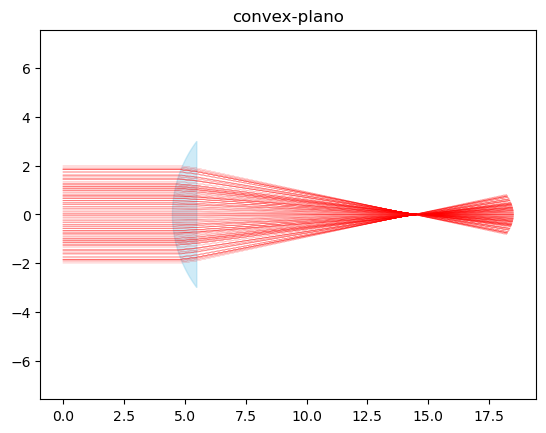

In [110]:
clearObjects()   #resets, clears the "board"
backgroundMedium(n=1)

number=100
randomYList=[]

for i in range(number):
    randomYList.append(np.random.uniform(-2, 2))
    
for randomY in randomYList:
    #symmetric
    Ray(y_pos=randomY, theta=0, x_pos=0)
    Ray(y_pos=-1*randomY, theta=0, x_pos=0)
    
ConvexLens(xc=5, yc=0, d=1, r1=5, r2=-50000, n=1.5, color='skyblue', points=1000)

move_allRays(anotherStep=13)

firstSetofObjects = objects.copy()

plotEverything(firstSetofObjects,"convex-plano", color='r')

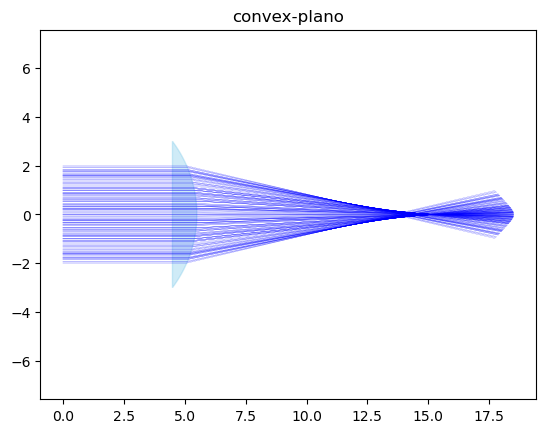

In [111]:
clearObjects()   #resets, clears the "board"
backgroundMedium(n=1)

number=100
randomYList=[]

for i in range(number):
    randomYList.append(np.random.uniform(-2, 2))
    
for randomY in randomYList:
    #symmetric
    Ray(y_pos=randomY, theta=0, x_pos=0)
    Ray(y_pos=-1*randomY, theta=0, x_pos=0)

ConvexLens(xc=5, yc=0, d=1, r1=50000, r2=-5, n=1.5, color='skyblue', points=1000)

move_allRays(anotherStep=13)

SecondSetofObjects = objects.copy()

plotEverything(SecondSetofObjects,"convex-plano", color='b')

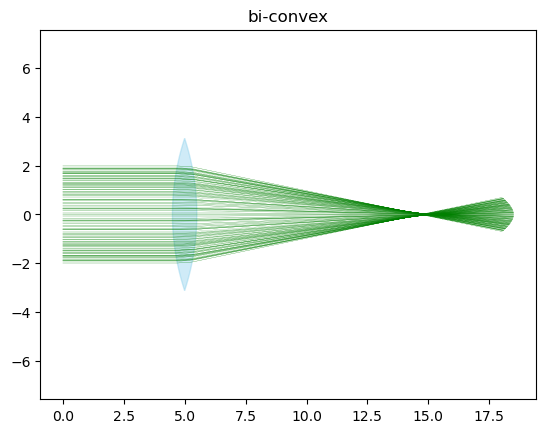

In [112]:
clearObjects()   #resets, clears the "board"
backgroundMedium(n=1)

number=100
randomYList=[]

for i in range(number):
    randomYList.append(np.random.uniform(-2, 2))
    
for randomY in randomYList:
    #symmetric
    Ray(y_pos=randomY, theta=0, x_pos=0)
    Ray(y_pos=-1*randomY, theta=0, x_pos=0)

ConvexLens(xc=5, yc=0, d=1, r1=10, r2=-10, n=1.5, color='skyblue', points=1000)

move_allRays(anotherStep=13)

ThirdSetofObjects = objects.copy()

plotEverything(ThirdSetofObjects,"bi-convex", color='g')

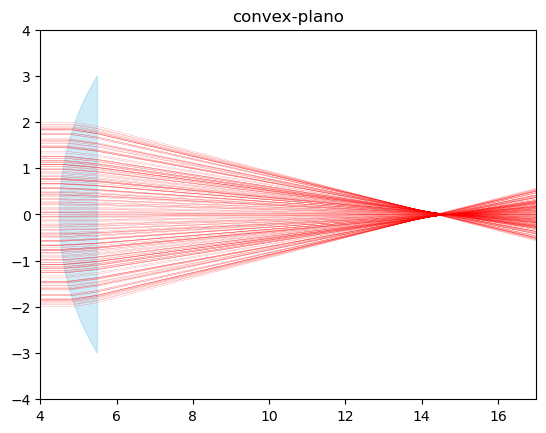

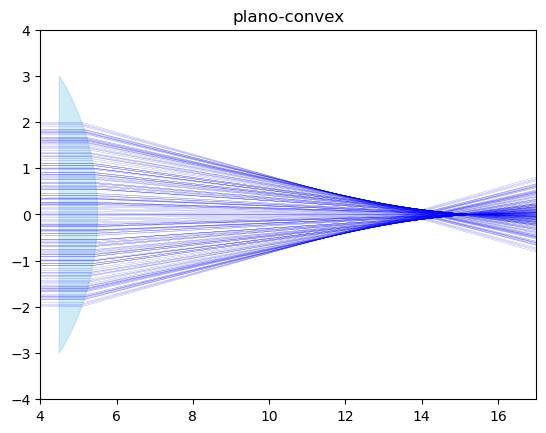

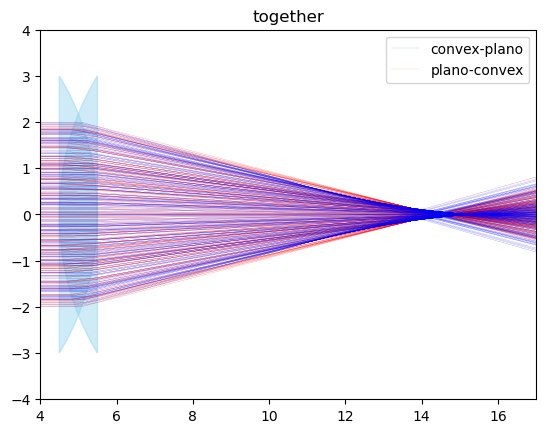

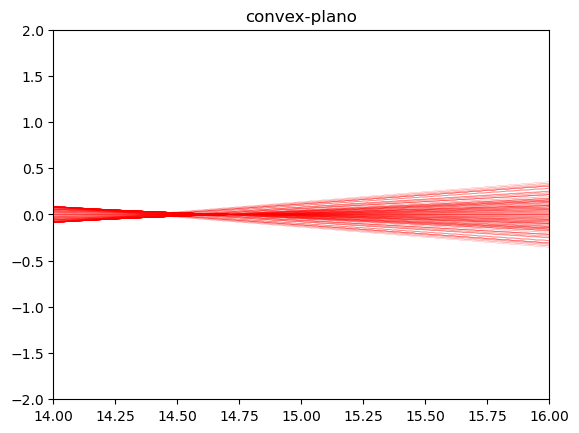

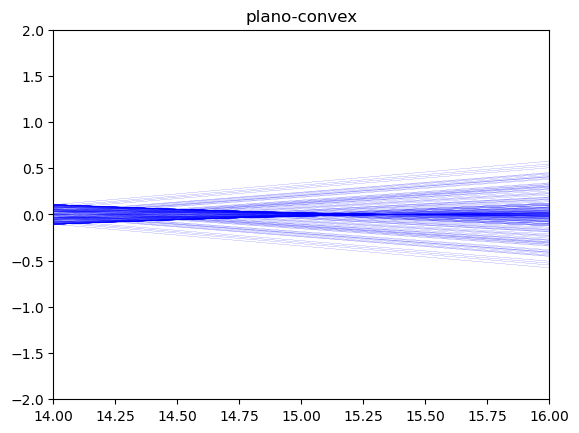

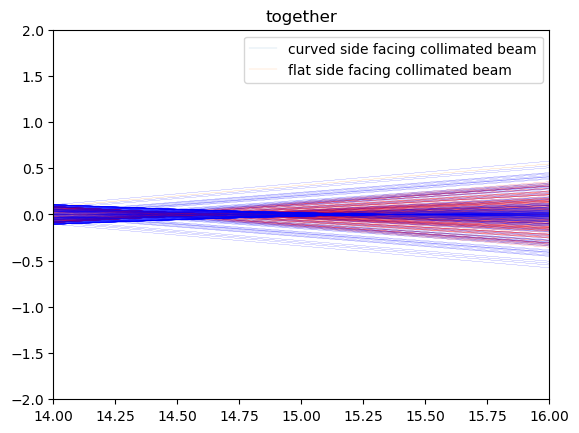

In [113]:
plotEverything(firstSetofObjects,"convex-plano",color='r',xlim=(4,17),ylim=(-4,4))
plotEverything(SecondSetofObjects,"plano-convex",color='b',xlim=(4,17),ylim=(-4,4))
# plotEverything(ThirdSetofObjects,title="bi-convex", color='g', xlim=(4,17),ylim=(-4,4))
plotMultipleObjects((firstSetofObjects,'r','convex-plano'),
                    (SecondSetofObjects,'b','plano-convex'),
                    # (ThirdSetofObjects,'g','bi-convex'),
                    title='together',
                    xlim=(4,17),
                    ylim=(-4,4))

plotEverything(firstSetofObjects,"convex-plano",color='r',xlim=(14,16),ylim=(-2,2))
plotEverything(SecondSetofObjects,"plano-convex",color='b',xlim=(14,16),ylim=(-2,2))
# plotEverything(ThirdSetofObjects,title="bi-convex", color='g', xlim=(14,16),ylim=(-2,2))
plotMultipleObjects((firstSetofObjects,'r','curved side facing collimated beam'),
                    (SecondSetofObjects,'b','flat side facing collimated beam'),
                    # (ThirdSetofObjects,'g','bi-convex'),
                    title='together',
                    xlim=(14,16),
                    ylim=(-2,2))

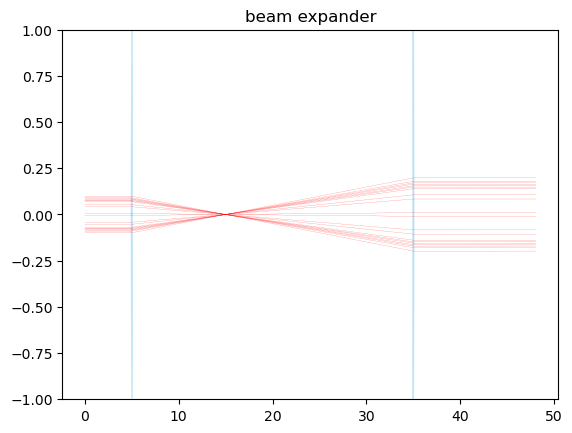

In [115]:
clearObjects()   #resets, clears the "board"
backgroundMedium(n=1)

number=10
randomYList=[]

for i in range(number):
    randomYList.append(np.random.uniform(-0.1, 0.1))
    
for randomY in randomYList:
    #symmetric
    Ray(y_pos=randomY, theta=0, x_pos=0)
    Ray(y_pos=-1*randomY, theta=0, x_pos=0)
    
ConvexLens(xc=5, yc=0, d=0.1, r1=5, r2=-50000, n=1.5, color='skyblue', points=100000)
ConvexLens(xc=35, yc=0, d=0.1, r1=50000, r2=-10, n=1.5, color='skyblue', points=100000)

move_allRays(anotherStep=13)

plotEverything(objects,"beam expander",ylim=(-1,1))

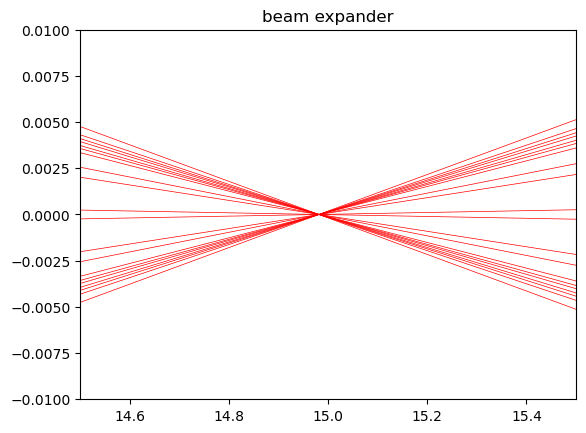

In [116]:
plotEverything(objects,"beam expander",xlim=(14.5,15.5),ylim=(-0.01,0.01), linewidth=0.5)